# Tema : Modelos ARIMA - SARIMA

![](src/img/logo_utb.png){width=40%}
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

# Ejercicio 1. Pronostico del PIB de Colombia.

- Usando los datos del Banco Mundial, estime un modelo ARIMA válido acorde a la teoría entre 1960-2024. Finalmente, realice el pronostico del PIB de Colombia para los próximos 5 años.



In [15]:
# Librerias necesarias
# install.packages(c("tidyverse", "tsibble", "feasts", "fable", "ggtime"))

# Librerias
library(tidyverse)
library(tsibble)
library(feasts)
library(fable)
library(ggtime)
library(patchwork)
library(tseries)

# datos banco mundial
library(wbstats)

# tamaño de los graficos
options(repr.plot.width = 6, repr.plot.height = 4)



    ‘tseries’ version: 0.10-59

    ‘tseries’ is a package for time series analysis and computational finance.

    See ‘library(help="tseries")’ for details.



Plot variable not specified, automatically selected `.vars = PIB`


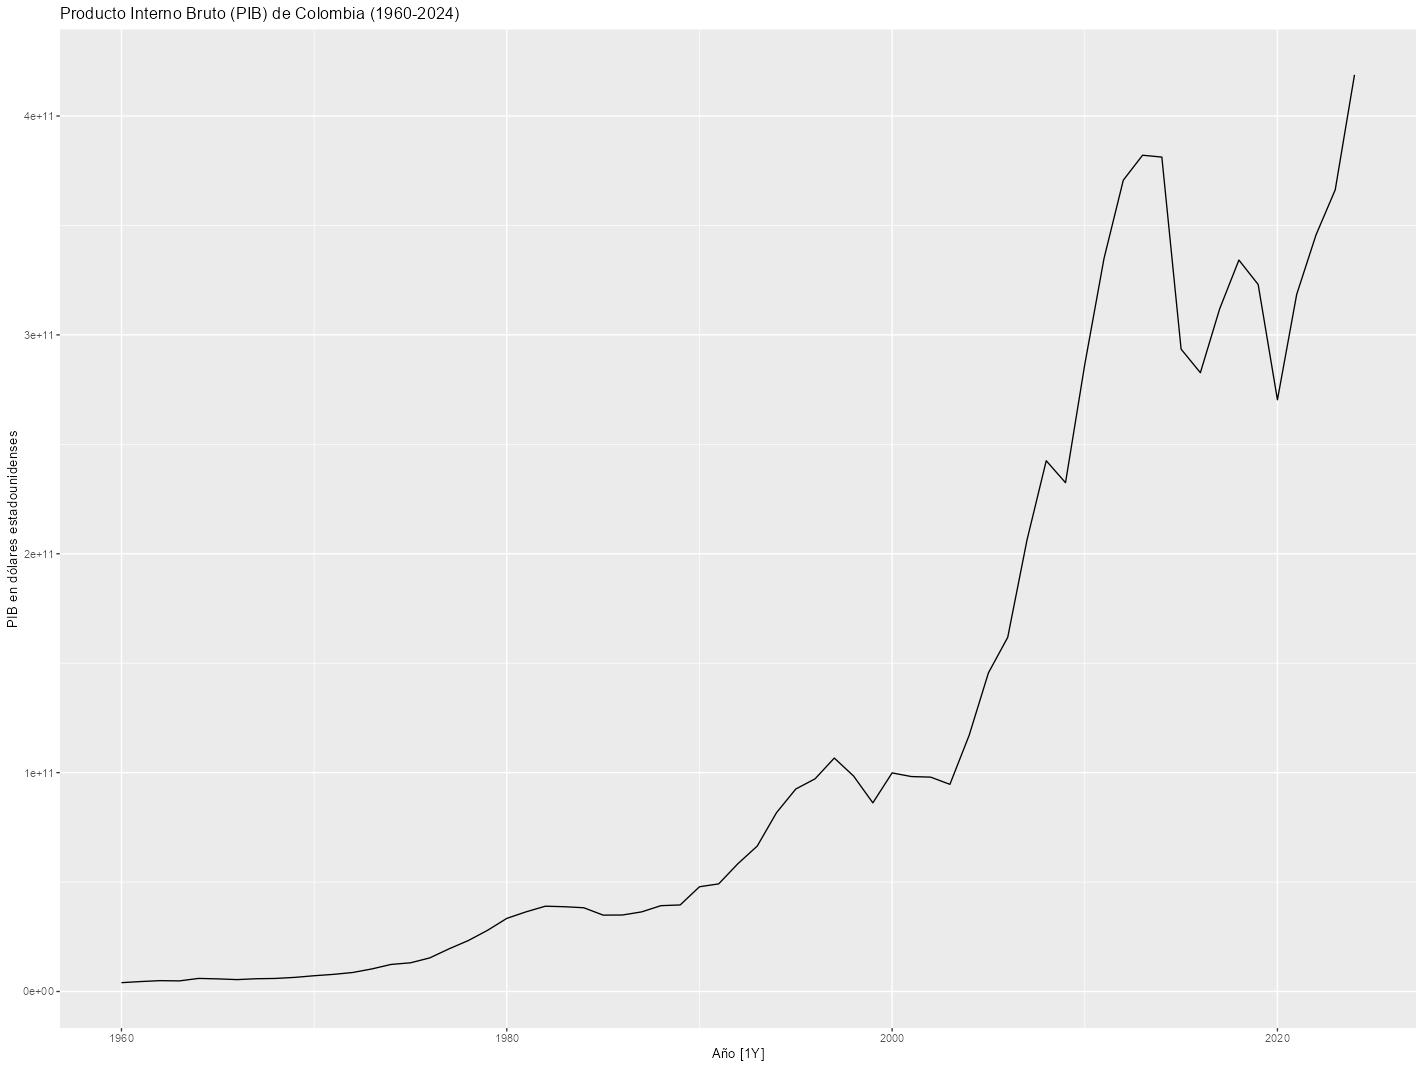

In [24]:
## Descargar los datos del Banco Mundial
data <- wb_data(indicator = 'NY.GDP.MKTP.CD', country = 'COL', start_date = 1960, end_date = 2024)
data <- data[, c('date', 'NY.GDP.MKTP.CD')]
colnames(data) <- c('Año', 'PIB')

# Ajustar la temporalidad de los periodos
data <- data |>
  as_tsibble(index = Año)


autoplot(data) +
  labs(title = 'Producto Interno Bruto (PIB) de Colombia (1960-2024)',
       y = 'PIB en dólares estadounidenses') 

## Verificar estacionaridad de la serie original

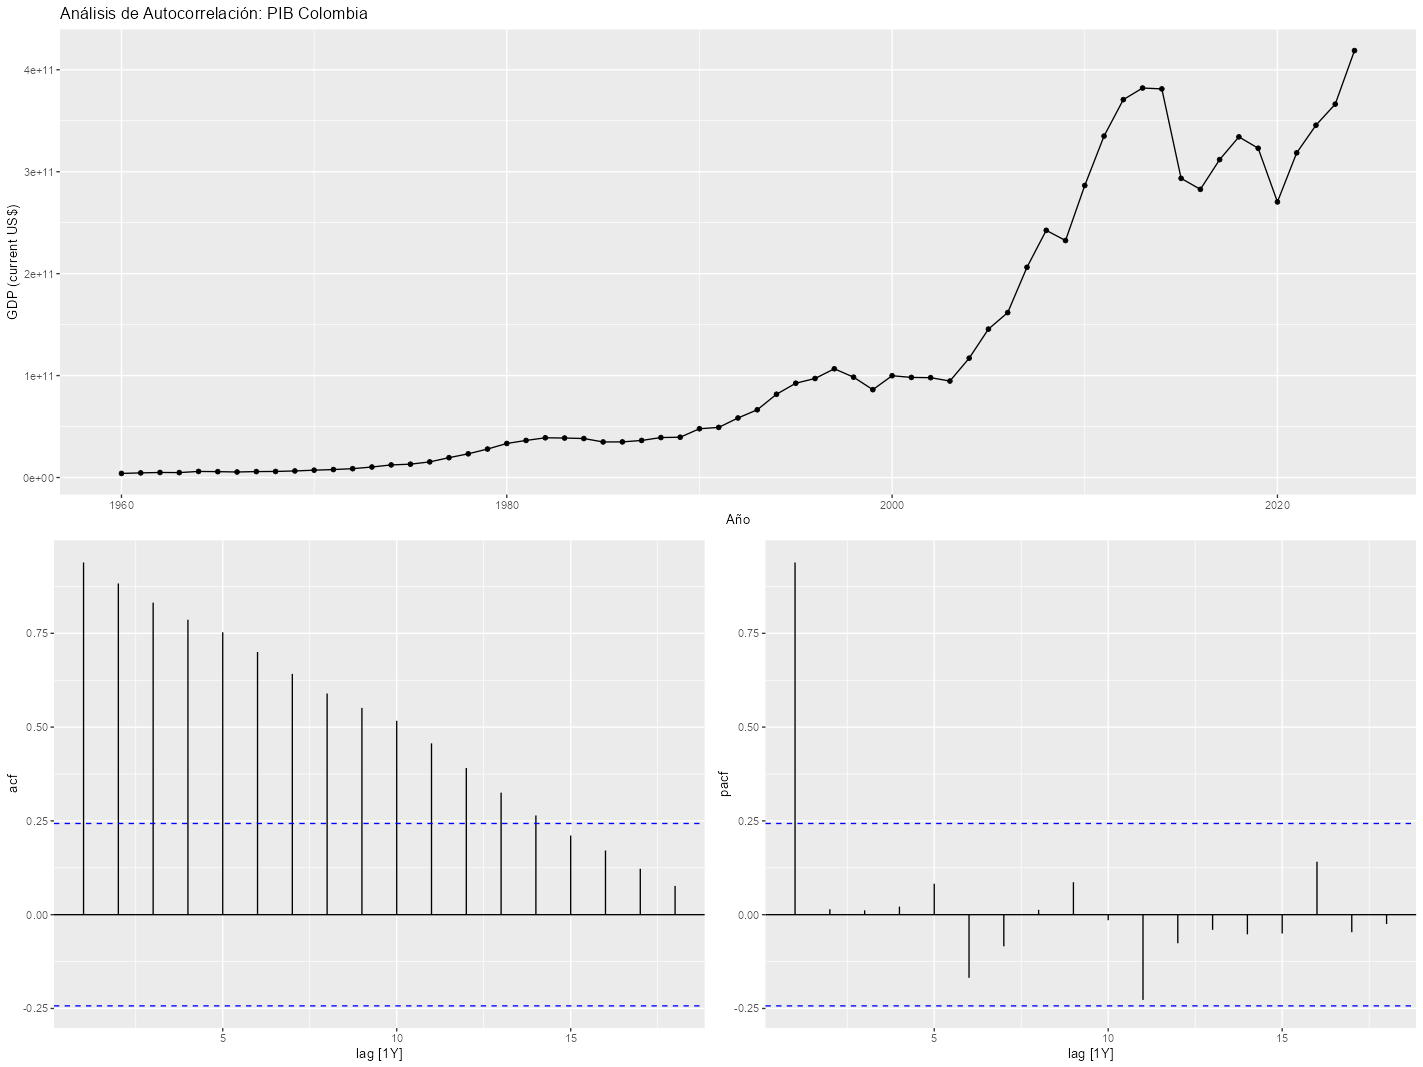

In [ ]:
data |> 
  gg_tsdisplay(PIB, plot_type = "partial") +
  labs(title = "Análisis de Autocorrelación: PIB Colombia")

In [18]:
# Test Ljung-Box
data |>
  features(PIB, ljung_box, lag = 10)

# A tibble: 1 × 2
  lb_stat lb_pvalue
    <dbl>     <dbl>
1    386.         0

In [33]:
# Augmented Dickey-Fuller
print(adf.test(data$PIB))
# KPSS
data |>
  features(PIB, unitroot_kpss)



	Augmented Dickey-Fuller Test

data:  data$PIB
Dickey-Fuller = -1.5908, Lag order = 3, p-value = 0.7409
alternative hypothesis: stationary



# A tibble: 1 × 2
  kpss_stat kpss_pvalue
      <dbl>       <dbl>
1      1.49        0.01

## Integración de la serie para estacionaridad

- Para integrar una serie con el fin de estabilizar la media y la varianza sacamos su primera diferencia

1. $E[Y_t] = \mu$ (constante) $\forall t$
2. $Var(Y_t) = \sigma^2$ (constante) $\forall t$
3. $Cov(Y_t, Y_{t+k}) = \gamma_k$ (solo depende del rezago $k$)

$$
\Delta y_t = y_t - y_{t-1}
$$

## Transformaciones usuales en las series económicas 

- Es usual transformar la series económicas en términos de crecimiento porcentual aplicando logaritmos y posterior tomar su primera diferencia que es equivalente a incremento porcentual.
- Como vimos en la transformación de Box-Cox (λ=0), el logaritmo ayuda a linealizar funciones exponenciales y varianza creciente.

$$
\Delta \log{y_t} = \log{y_t} - \log{y_{t-1}} = \log{\frac{y_t}{y_{t-1}}} \sim \%\Delta y_t
$$

Warning messages:
1: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 1 row containing missing values or values outside the scale range (`geom_point()`). 


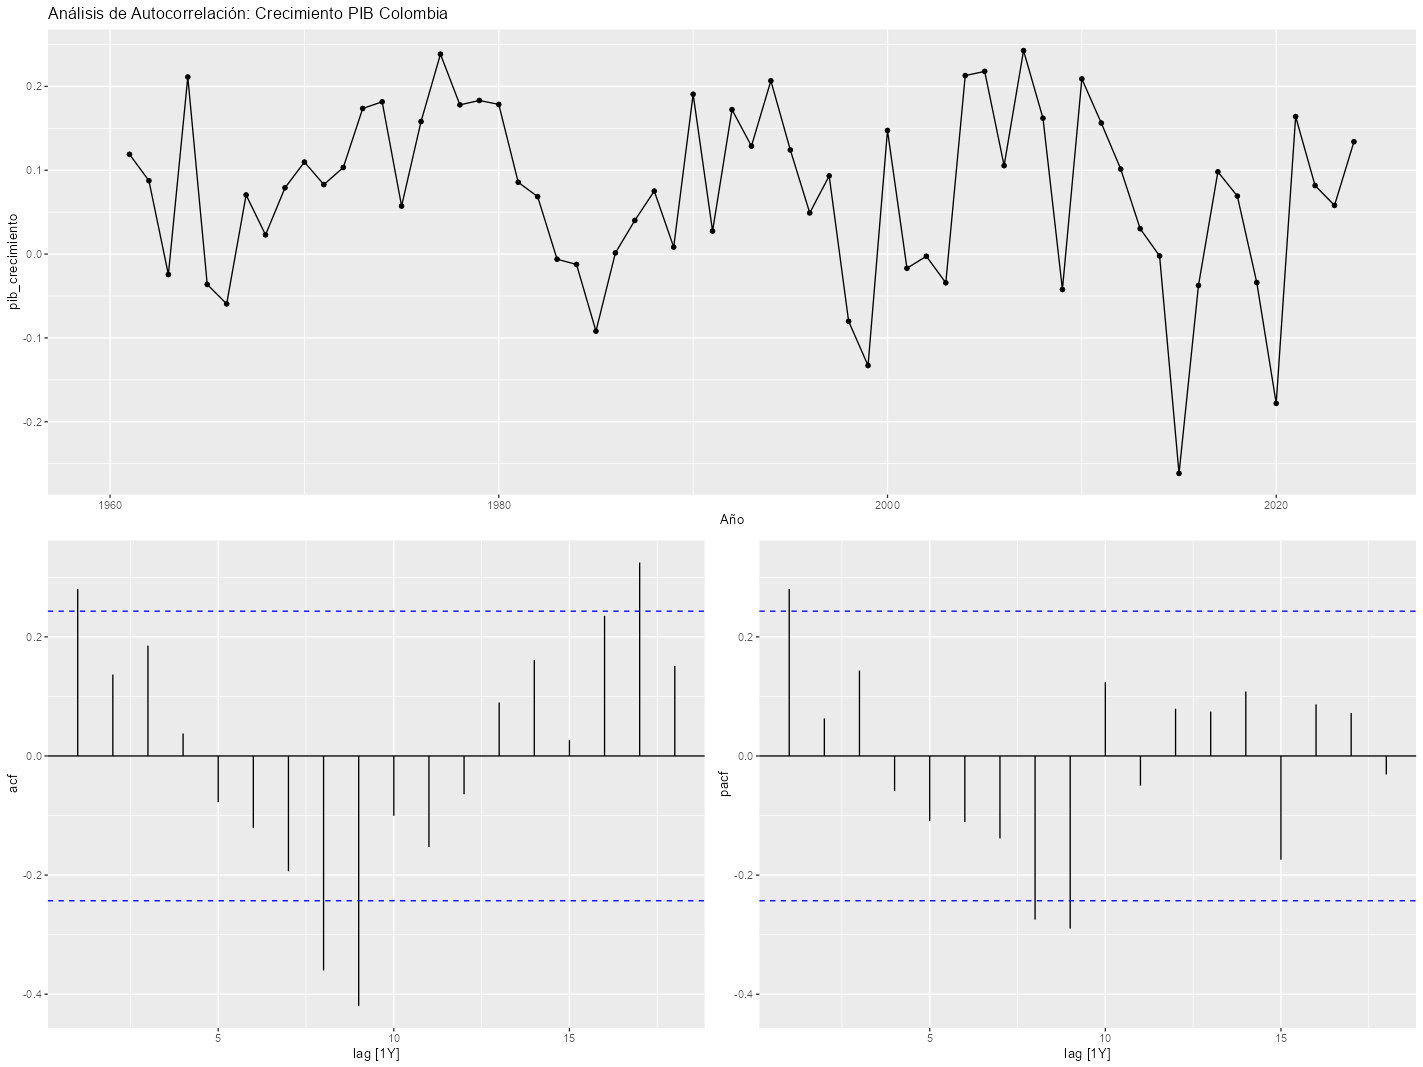

# A tibble: 1 × 2
  kpss_stat kpss_pvalue
      <dbl>       <dbl>
1     0.125         0.1

In [30]:
data <- data |>
  mutate(
    # Primera diferencia de la serie integrada de orden 1
    pib_diff = difference(PIB),
    # Tomamos el logaritmo y la primera diferencia. Esto transforma la serie en tasas de crecimiento
    pib_crecimiento = difference(log(PIB))
  )
  
data |> 
  gg_tsdisplay(pib_crecimiento, plot_type = "partial") +
  labs(title = "Análisis de Autocorrelación: Crecimiento PIB Colombia")

# Test estacionariedad
data |>
  features(pib_crecimiento, unitroot_kpss)

## Estimación modelos ARIMA

In [39]:
# ARIMA(1, 1, 0)
modelos_arima <- data |>
  model(
    arima110 = ARIMA(pib_crecimiento ~ pdq(1, 0, 0)),
    arima011 = ARIMA(pib_crecimiento ~ pdq(0, 0, 1)),
    arima011 = ARIMA(pib_crecimiento ~ pdq(1, 0, 1)),
    auto_arima = ARIMA(pib_crecimiento, stepwise=FALSE)
  )

modelos_arima |> 
  select(arima011) |>
  report()

Series: pib_crecimiento 
Model: ARIMA(1,0,1) w/ mean 

Coefficients:
         ar1      ma1  constant
      0.5671  -0.3176    0.0318
s.e.  0.2763   0.3129    0.0084

sigma^2 estimated as 0.01018:  log likelihood=56.94
AIC=-105.87   AICc=-105.2   BIC=-97.17


In [70]:
# Mejor modelo segun AIC
glance(modelos_arima) |> 
  arrange(AICc) |> 
  select(.model:BIC) |>
  print()

mejor_arima <- modelos_arima |> select(auto_arima)
mejor_arima |> 
  report() |>
  print()

# A tibble: 3 × 6
  .model      sigma2 log_lik   AIC  AICc    BIC
  <chr>        <dbl>   <dbl> <dbl> <dbl>  <dbl>
1 auto_arima 0.00887    62.8 -110. -107.  -92.3
2 arima110   0.0101     56.7 -107. -107. -101. 
3 arima011   0.0102     56.9 -106. -105.  -97.2
Series: pib_crecimiento 
Model: ARIMA(2,0,4) w/ mean 

Coefficients:
         ar1      ar2      ma1     ma2     ma3      ma4  constant
      1.7837  -0.9282  -1.7060  0.7370  0.3236  -0.2361    0.0109
s.e.  0.0695   0.0659   0.1345  0.2371  0.2511   0.1612    0.0014

sigma^2 estimated as 0.008871:  log likelihood=62.84
AIC=-109.68   AICc=-107.11   BIC=-92.28
# A mable: 1 x 1
              auto_arima
                 <model>
1 <ARIMA(2,0,4) w/ mean>


Warning messages:
1: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 1 row containing missing values or values outside the scale range (`geom_point()`). 
3: Removed 1 row containing non-finite outside the scale range (`stat_bin()`). 
4: Removed 1 row containing missing values or values outside the scale range (`geom_rug()`). 


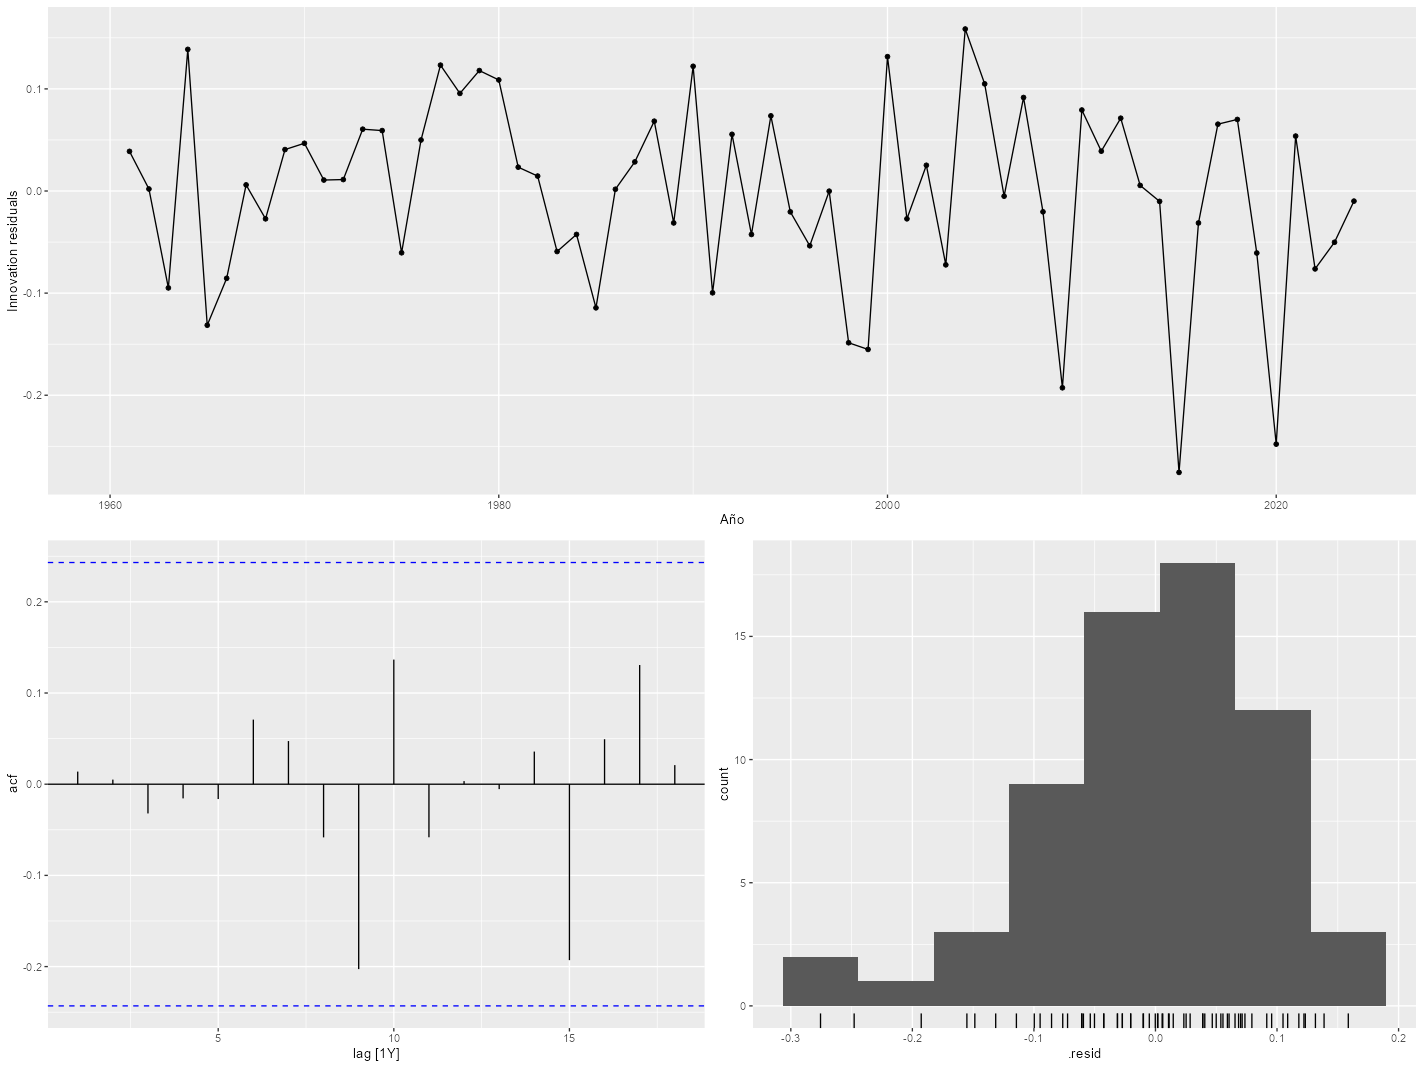

# A tibble: 1 × 3
  .model     lb_stat lb_pvalue
  <chr>        <dbl>     <dbl>
1 auto_arima    5.53     0.853

In [52]:
# Verificar ruido blanco
mejor_arima |> gg_tsresiduals()

# Verificar ruido blanco
augment(mejor_arima) |>
  features(.resid, ljung_box, lag = 10)

## Pronóstico mejor modelo modelo crecimiento PIB

Acorde al DANE En 2024p, el Producto Interno Bruto (PIB) presenta un crecimiento de 1,5% respecto a 2023. El modelo pronosticó 0,68% de incremento para 2024 respecto a 2023.
https://www.dane.gov.co/index.php/estadisticas-por-tema/cuentas-nacionales/cuentas-nacionales-anuales

Warning message:
Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 


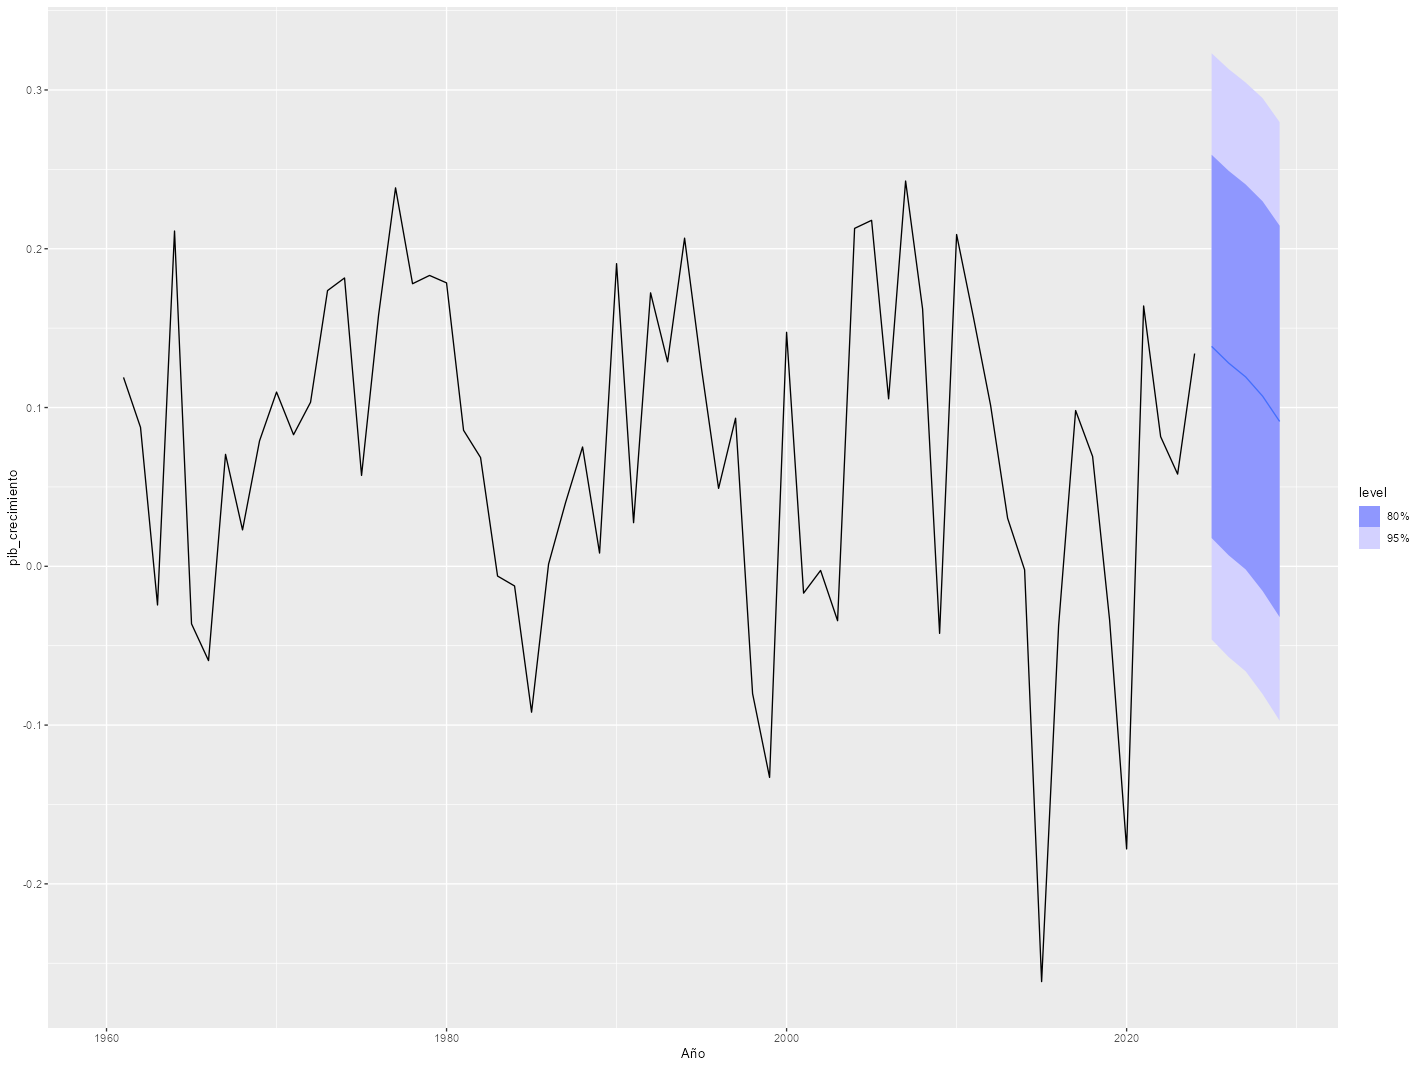

In [69]:
# Pronostico de los proximos 5 años
mejor_arima |>
  forecast(h = 5) |>
  autoplot(data)

In [68]:
# Tabla de pronóstico 
mejor_arima |> 
  forecast(h = 5) |> 
  hilo(level = c(80, 95)) |> 
  unpack_hilo(c("80%", "95%")) |> 
  as.data.frame()

      .model  Año            pib_crecimiento      .mean    80%_lower 80%_upper   95%_lower 95%_upper
1 auto_arima 2025  N(0.1385122, 0.008871189) 0.13851217  0.017806684 0.2592176 -0.04609094 0.3231153
2 auto_arima 2026  N(0.1280201, 0.008924846) 0.12802009  0.006950113 0.2490901 -0.05714046 0.3131806
3 auto_arima 2027  N(0.1192869, 0.008949277) 0.11928688 -0.001948686 0.2405225 -0.06612692 0.3047007
4 auto_arima 2028  N(0.1071401, 0.009170275) 0.10714007 -0.015583297 0.2298634 -0.08054912 0.2948293
5 auto_arima 2029 N(0.09124388, 0.009248973) 0.09124388 -0.032004956 0.2144927 -0.09724895 0.2797367

## Pronostico en sus niveles del PIB

- Reversar la transformación logarítmico del crecimiento
$$
\Delta \log(PIB_t) = \log(PIB_t) - \log(PIB_{t-1})  \\
PIB_{t+h} = PIB_{t} * \exp^{\sum^{h}_{i=1}\Delta \log(PIB_t)}
$$


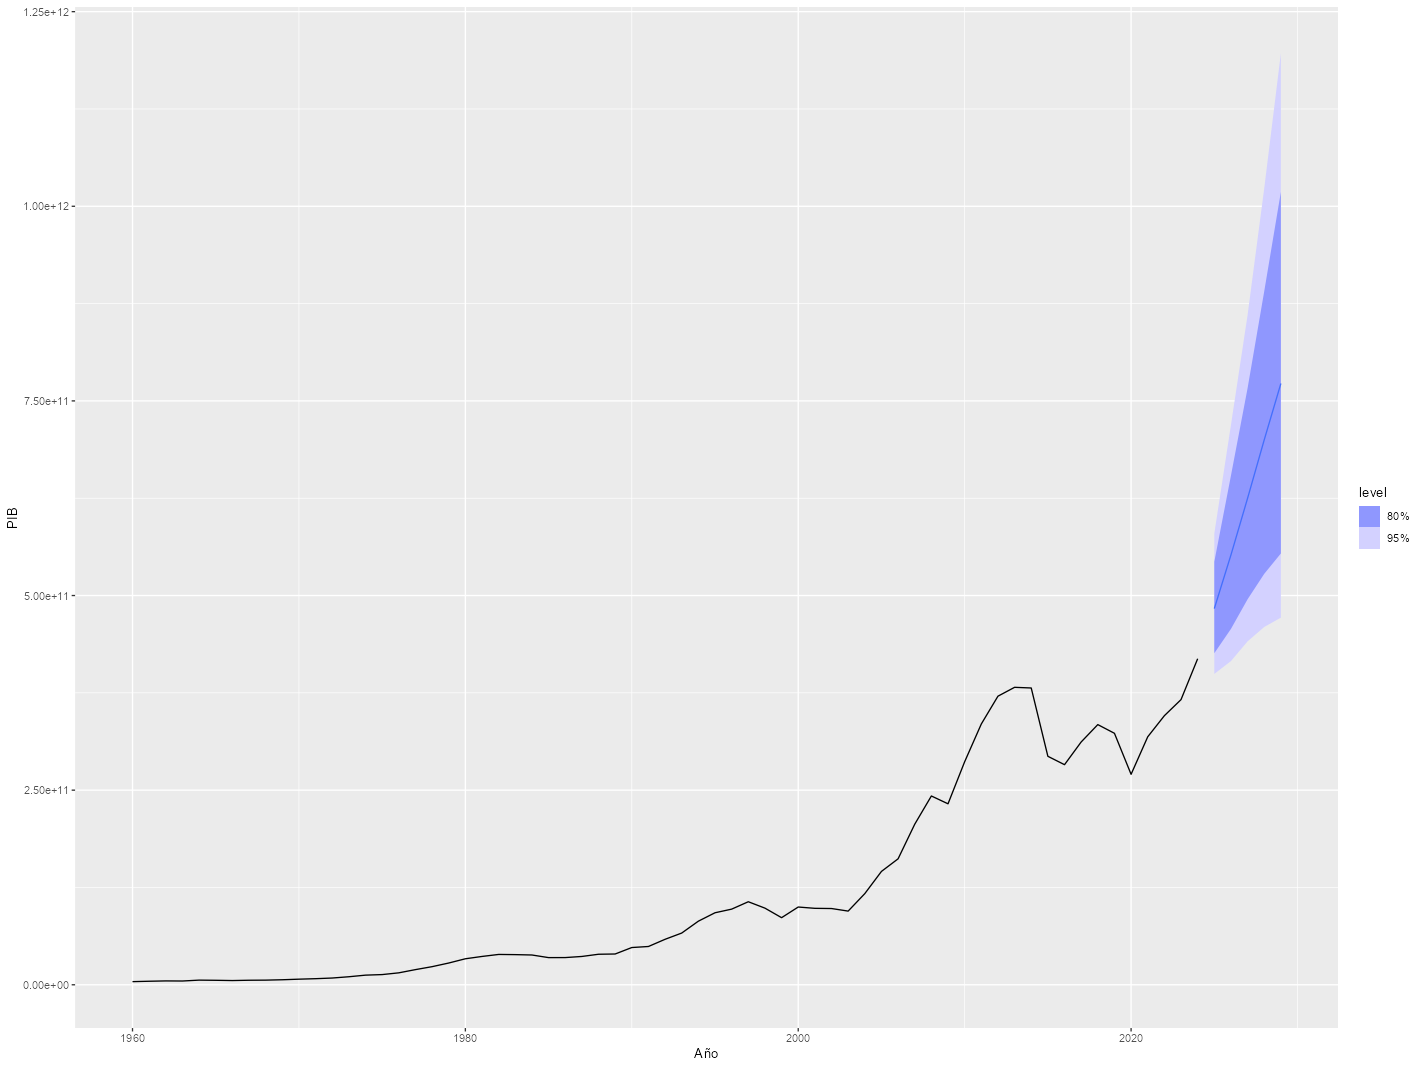

In [ ]:
# Estimar log-diferencia a niveles
fit <- data |>
  model(
    mejor_modelo = ARIMA(log(PIB) ~ pdq(2, 1, 4))
  )

pronostico <- fit |> 
  forecast(h = 5)

pronostico |> 
  autoplot(data)


# Ejemplo 2. Empleo mensual en el sector de ocio y hostelería en EE. UU

Describiremos la modelización ARIMA estacional utilizando datos mensuales de empleo en Estados Unidos para los trabajos de ocio y hospitalidad desde enero de 2001 hasta septiembre de 2019.

Rows: 143412 Columns: 3
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): unique_id
dbl  (1): y
date (1): ds

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Plot variable not specified, automatically selected `.vars = y`


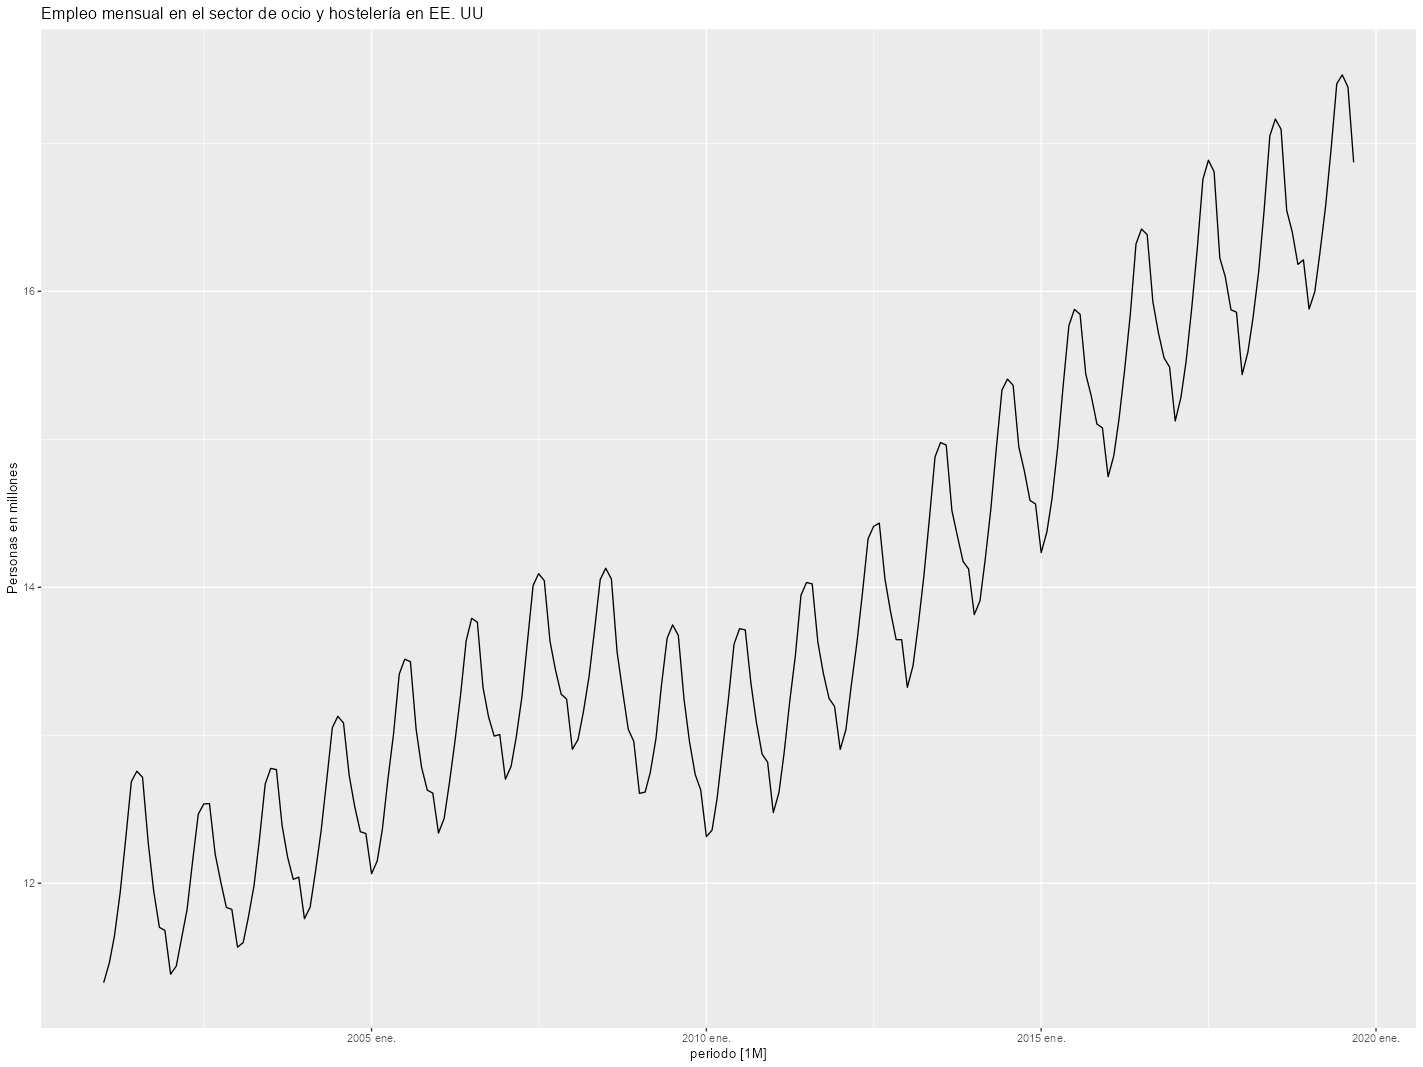

In [81]:
# leer y ajustar datos
datos <- read_csv("data/us_employment.csv")
datos <- datos |>
  filter(ds >= as.Date("2001-01-01"), unique_id == "Leisure and Hospitality") |>
  mutate(y = y / 1e3, periodo = yearmonth(ds)) |>
  as_tsibble(index = periodo)

# grafico serie
datos |>
  autoplot() + 
  labs(y = 'Personas en millones', title = 'Empleo mensual en el sector de ocio y hostelería en EE. UU')

Los datos son claramente no estacionarios, con una fuerte estacionalidad y una tendencia no lineal, por lo que primero tomaremos una diferencia estacional. Los datos con diferencia estacional se muestran en la figura siguiente.


Warning messages:
1: Removed 12 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 12 rows containing missing values or values outside the scale range (`geom_point()`). 


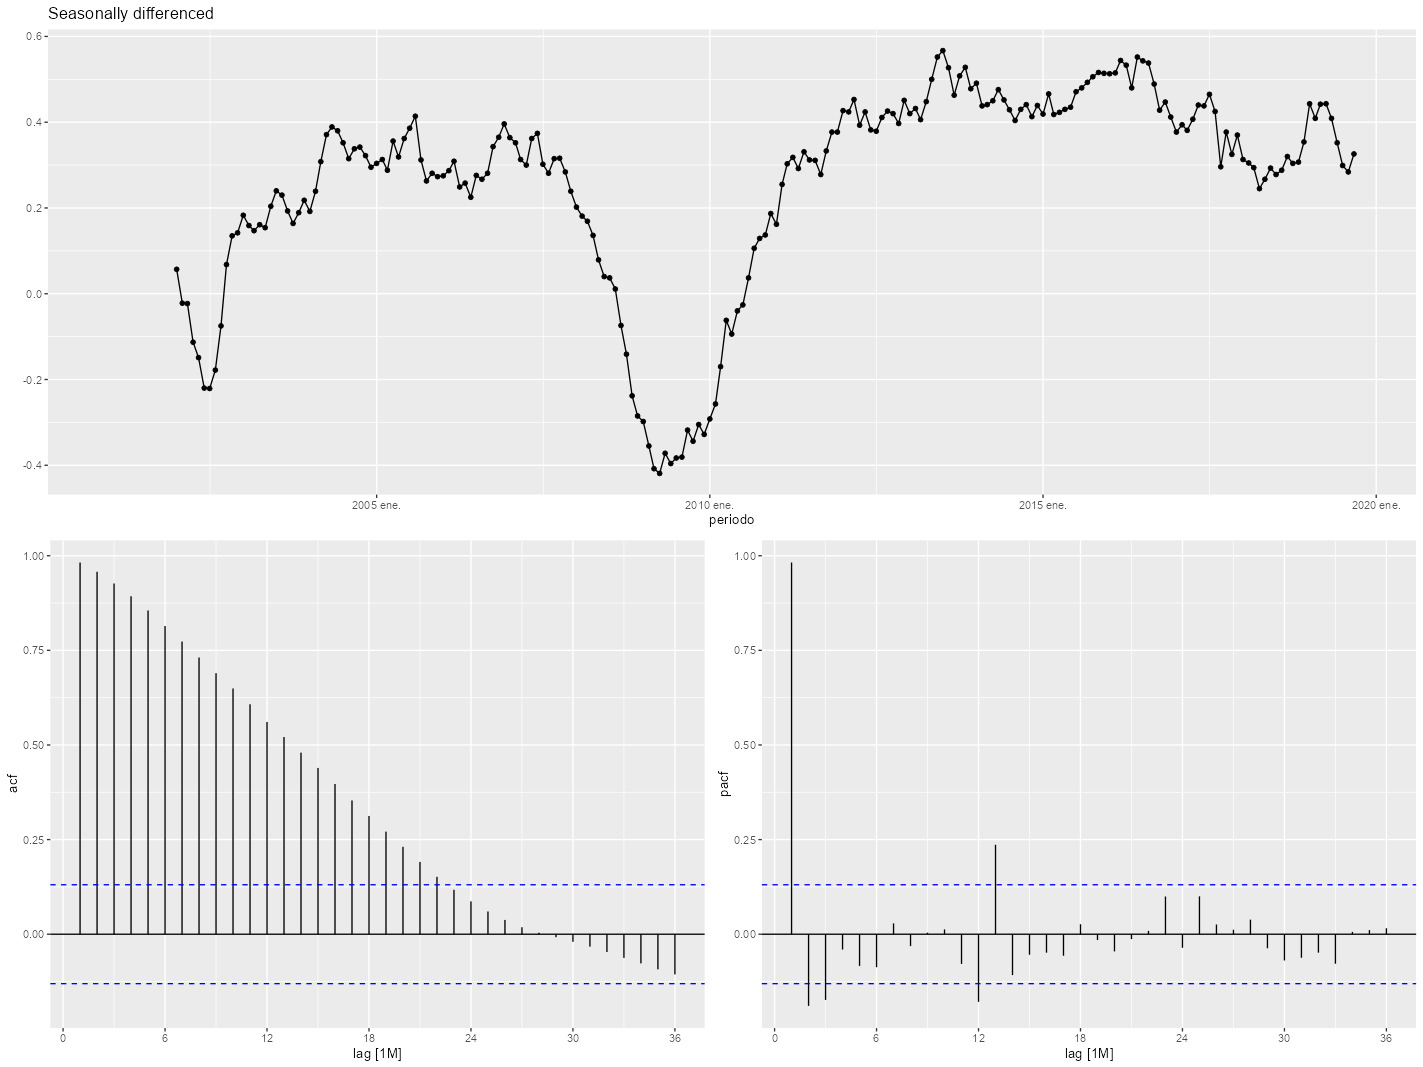

In [84]:
# Diferencia estacional
datos |>
  gg_tsdisplay(difference(y, 12),
               plot_type='partial', lag=36) +
  labs(title="Seasonally differenced", y="")

Estos también son claramente no estacionarios, por lo que tomamos una primera diferencia adicional, ver figura siguiente.

Warning messages:
1: Removed 13 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 13 rows containing missing values or values outside the scale range (`geom_point()`). 


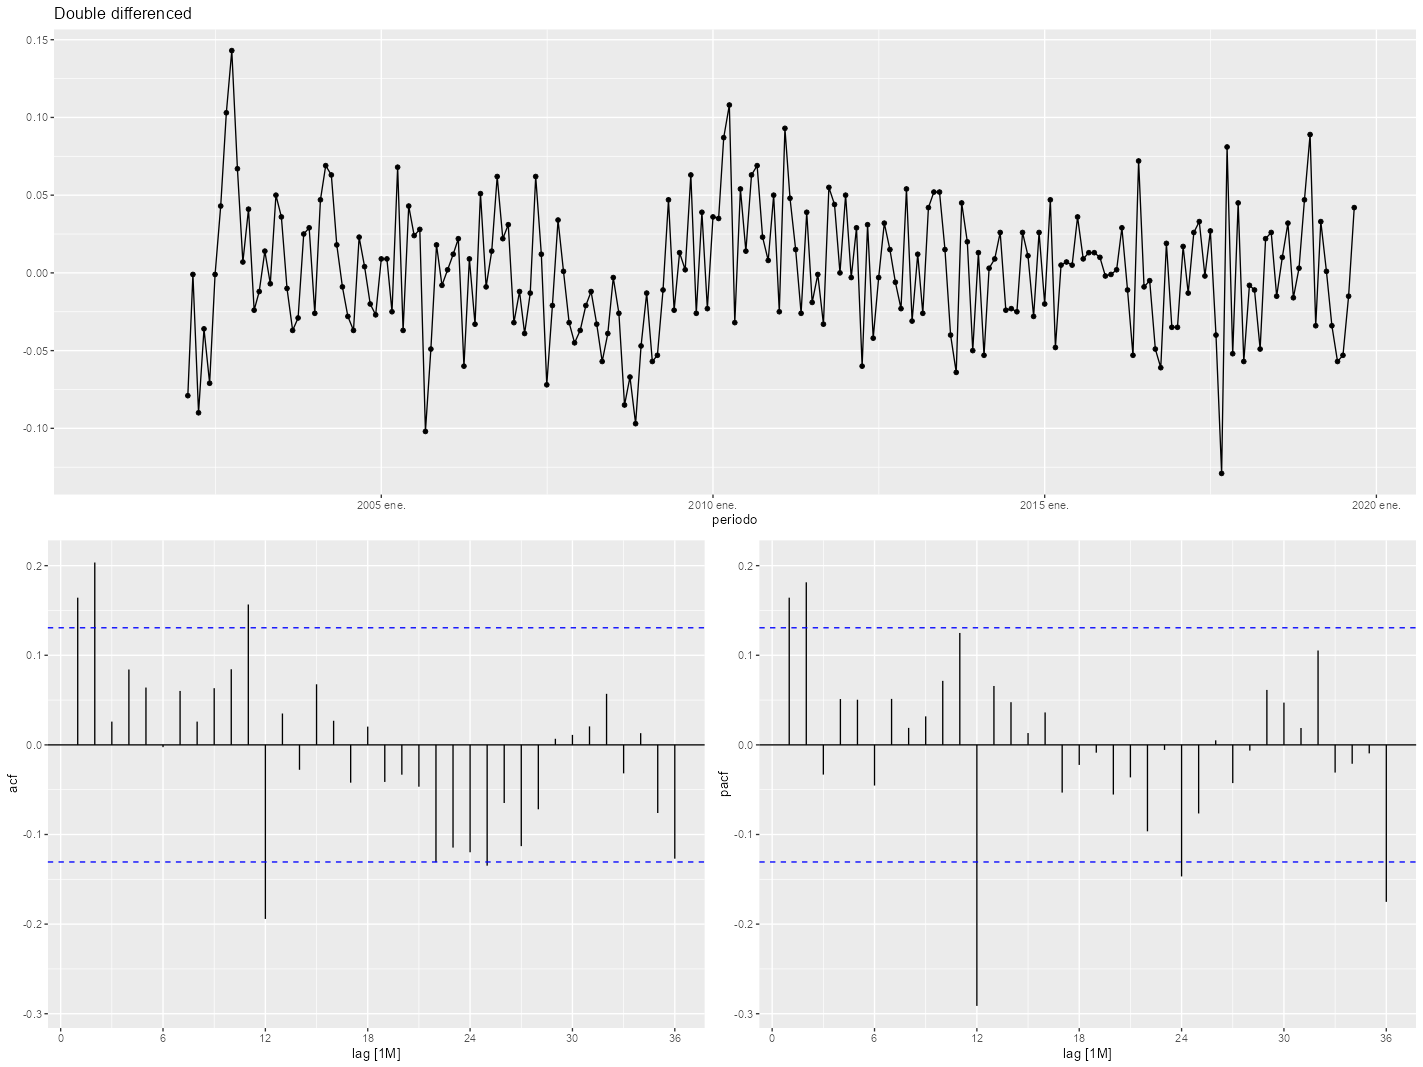

In [85]:
datos |>
  gg_tsdisplay(difference(y, 12) |> difference(),
               plot_type='partial', lag=36) +
  labs(title = "Double differenced", y="")

In [86]:
# test estacionariedad
datos |>
  features(difference(y, 12) |> difference(), unitroot_kpss)

# A tibble: 1 × 2
  kpss_stat kpss_pvalue
      <dbl>       <dbl>
1    0.0849         0.1

## Definición del modelo
- Nuestro objetivo ahora es encontrar un modelo ARIMA apropiado basándonos en la ACF y la PACF mostradas en la figura anterior. 
- El pico significativo en el rezago 2 de la ACF sugiere un componente MA(2) no estacional. 
- El pico significativo en el rezago 12 de la ACF sugiere un componente MA(1) estacional. 
- En consecuencia, comenzamos con un modelo $ARIMA(0,1,2)(0,1,1)_12$, que indica una primera diferencia, una diferencia estacional y componentes MA(2) no estacional y MA(1) estacional. 
- Si hubiéramos partido de la PACF, podríamos haber seleccionado un modelo $ARIMA(2,1,0)(0,1,1)_12$
- Usando la PACF para seleccionar la parte no estacional del modelo y la ACF para seleccionar la parte estacional. También incluiremos un modelo seleccionado automáticamente.

## Construcción del modelo SARIMA (0,1,2)(0,1,1)12​
- Parte Regular (0,1,2):
    - p = 0 : No componente autoregresivo
    - d = 1: Estás tomando una diferencia para eliminar la tendencia
    - q = 2: El valor de hoy depende de los errores de los dos meses anteriores
- Parte Estacional (0,1,1,12):
    - P = 0 : No componente autoregresivo
    - D = 1 : Estás restando el valor del mismo mes del año anterior ($Y_t​−Y_{t−12}$​) para eliminar el patrón anual.
    - Q = 1 : El error de este mes está correlacionado con el error del mismo mes del año pasado.
    - s = 12 : Define el ciclo estacional ocurre cada 12 observaciones.

In [88]:
# Estimar modelos SARIMA
fit_modelos <- datos |>
  model(
    arima012011 = ARIMA(y ~ pdq(0,1,2) + PDQ(0,1,1)),
    arima210011 = ARIMA(y ~ pdq(2,1,0) + PDQ(0,1,1)),
    auto = ARIMA(y, stepwise = FALSE, approx = FALSE) # Búsqueda exhaustiva (revisa todas las combinaciones)
  )


In [ ]:
# mejor modelo
glance(fit_modelos) |> arrange(AICc) |> select(.model:BIC)

# A tibble: 3 × 6
  .model       sigma2 log_lik   AIC  AICc   BIC
  <chr>         <dbl>   <dbl> <dbl> <dbl> <dbl>
1 auto        0.00142    395. -780. -780. -763.
2 arima210011 0.00145    392. -776. -776. -763.
3 arima012011 0.00146    391. -775. -775. -761.

In [96]:
# Reporte modelo
mejor_modelo <- fit_modelos |> select(auto)
mejor_modelo |> report()

Series: y 
Model: ARIMA(2,1,0)(1,1,1)[12] 

Coefficients:
         ar1     ar2    sar1     sma1
      0.1786  0.1855  0.3295  -0.7507
s.e.  0.0695  0.0679  0.1273   0.0936

sigma^2 estimated as 0.001415:  log likelihood=394.96
AIC=-779.92   AICc=-779.63   BIC=-763.14


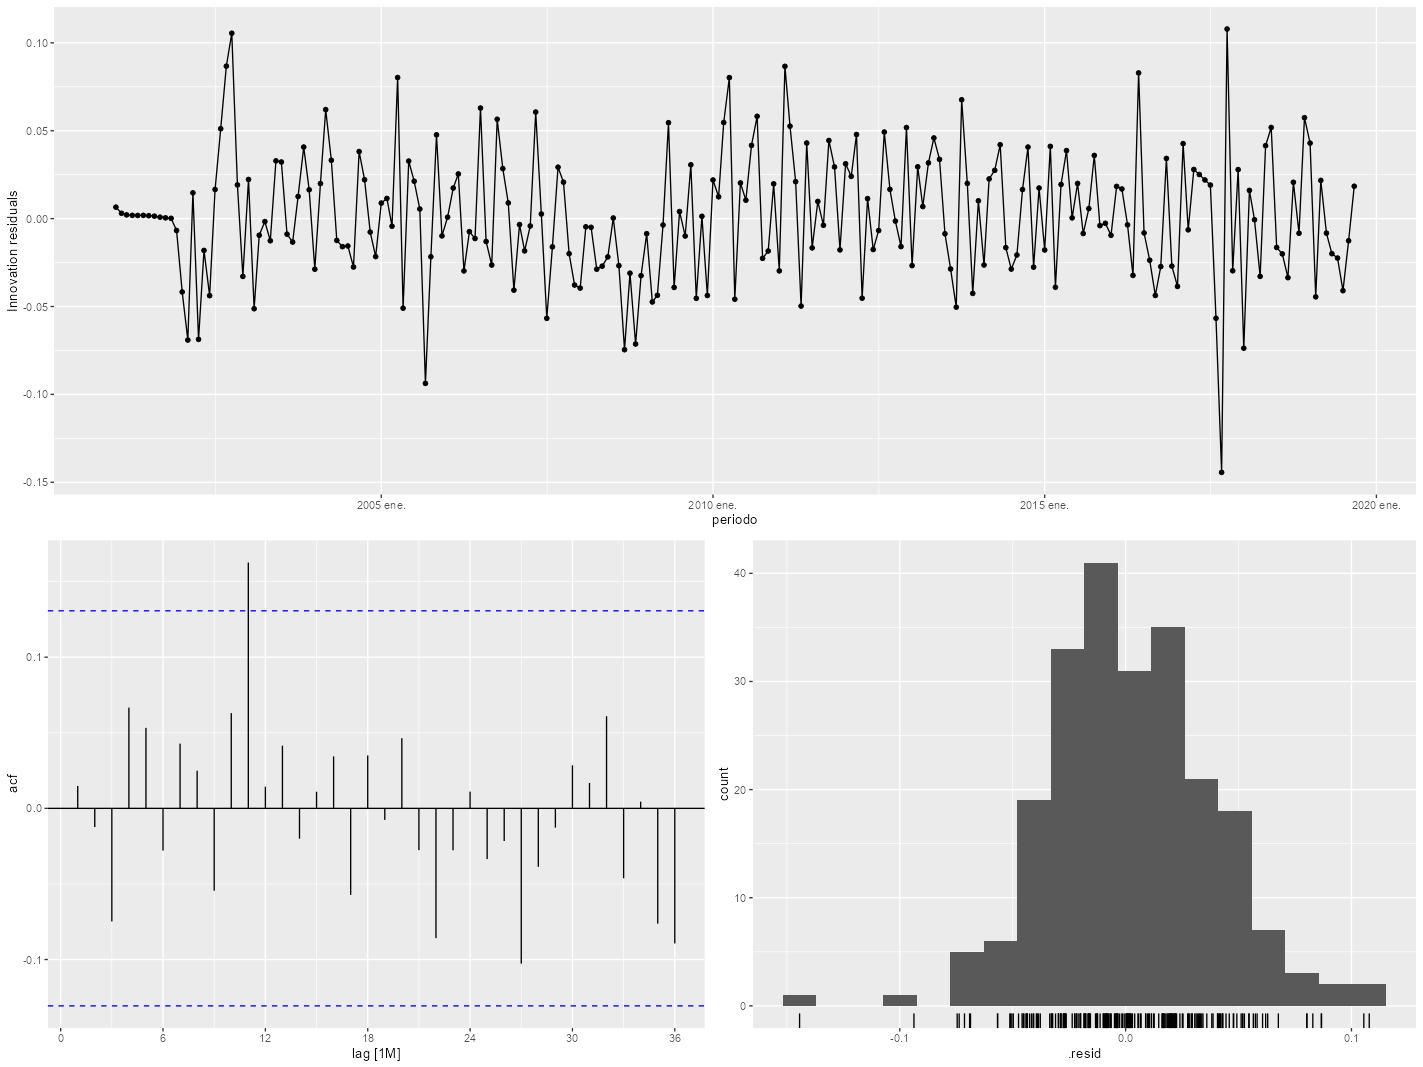

# A tibble: 1 × 3
  .model lb_stat lb_pvalue
  <chr>    <dbl>     <dbl>
1 auto    0.0500     0.823

In [98]:
# Verificar ruido blanco
# Diagnostico del modelo
mejor_modelo |> gg_tsresiduals(lag=36)

augment(mejor_modelo) |>
  features(.innov, ljung_box)

## Pronóstico mejor modelo
Así, ahora contamos con un modelo ARIMA estacional que supera las verificaciones requeridas y está listo para realizar pronósticos. 
- Los pronósticos del modelo para los próximos tres años se muestran en la figura siguiente. 
- Los pronósticos han captado muy bien el patrón estacional, y la tendencia creciente extiende el patrón reciente. La tendencia en los pronósticos está inducida por la doble diferenciación.

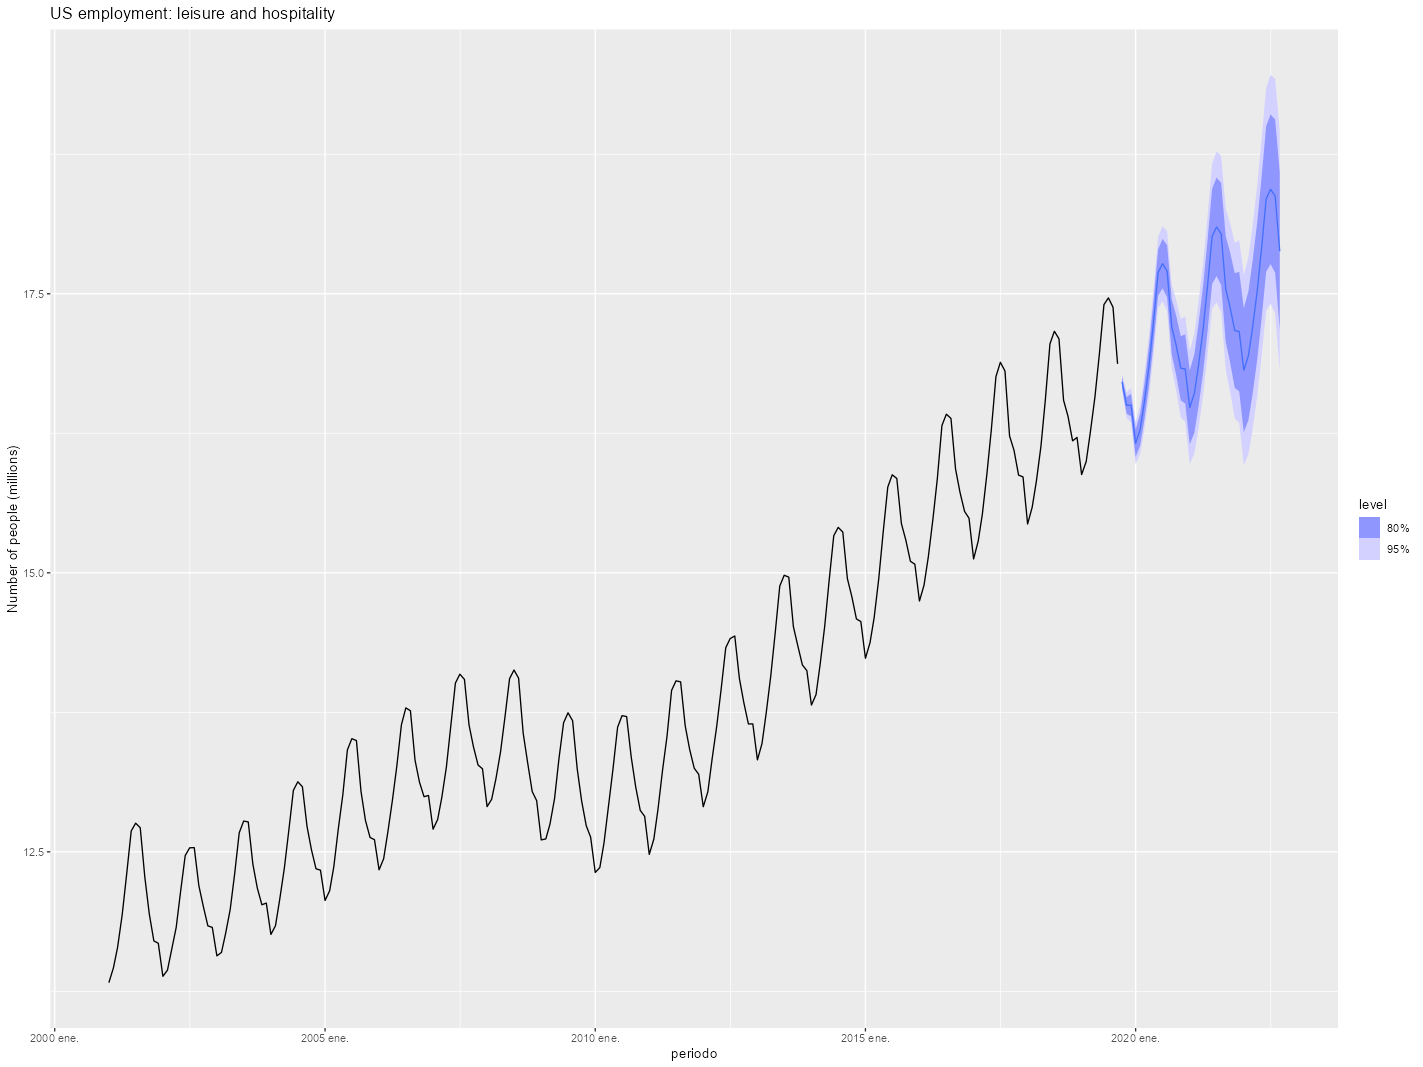

In [99]:
# Pronostico de los proximos 3 años = 12 meses * 3 años  = 36
forecast(mejor_modelo, h=36) |>
  autoplot(datos) +
  labs(title = "US employment: leisure and hospitality",
       y="Number of people (millions)")

# Ejemplo 3 : El modelo macroeconómico del crecimiento del consumo en Estados Unidos

- Queremos modelar cómo cambia el consumo real (compra de bienes y servicios) de una economía según el incremento del ingreso.
$$
\Delta C_t = \beta_0 + \beta_1 \Delta Ingreso_t + \varepsilon_t
$$

- $\Delta C_t$ es el cambio porcentual en el gasto real de consumo personal.
- $Ingreso_t$​ es el cambio porcentual en el ingreso personal real disponible.

- Usar el archivo `US_change.csv` para modelar.

# Ejemplo 4 : Gasto en publicidad por televisión y cotizaciones de seguros

Una empresa de seguro en EEUU está interesada en saber si el gasto en publicidad por televisión influye en el valor de los aportes de aseguramiento. Para ello tiene dos series de tiempo, uno con el gasto en publicidad y la otra en aportes de seguro que realiza los clientes.